# Import libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load Dataset

In [58]:
df = pd.read_csv('data/Clean_Dataset.csv')

# Initial Exploration

In [59]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [61]:
df.shape

(300153, 12)

In [62]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [63]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning and Transformation

In [65]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [91]:
df.drop('flight', axis=1, inplace=True)

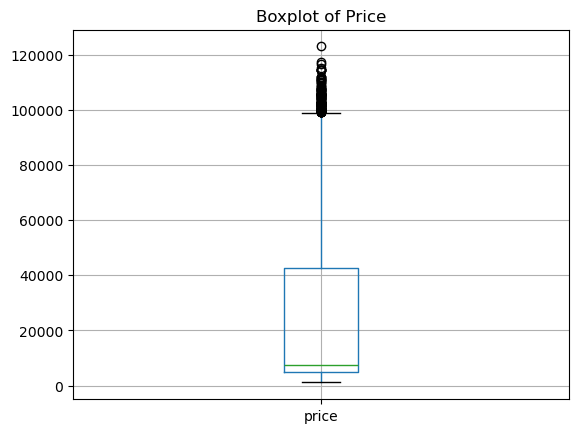

In [92]:
boxplot = df.boxplot(column='price')
plt.title('Boxplot of Price')
plt.show()

In [93]:
df.columns

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')

In [94]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

In [95]:
categorical_cols

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class'],
      dtype='object')

In [96]:
numerical_cols

Index(['duration', 'days_left', 'price'], dtype='object')

In [97]:
categorical_cols.size + numerical_cols.size

10

In [98]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# EDA

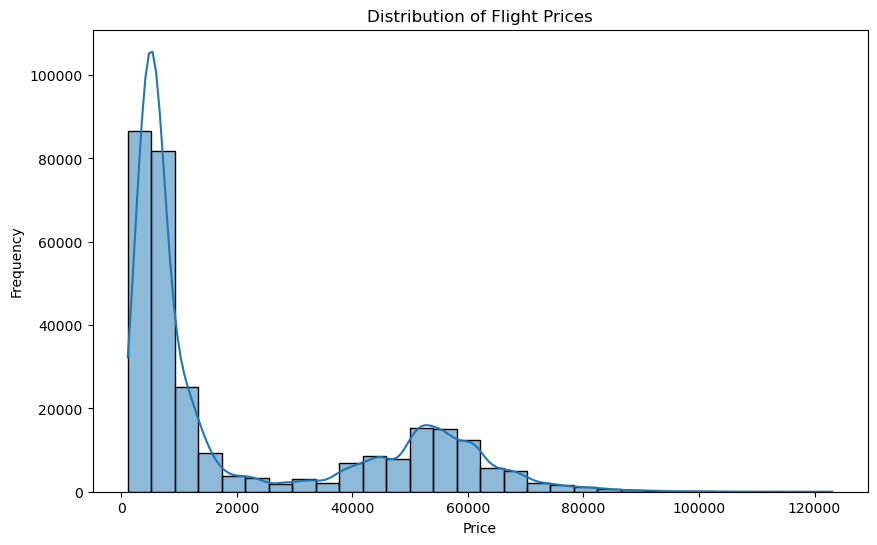

In [99]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

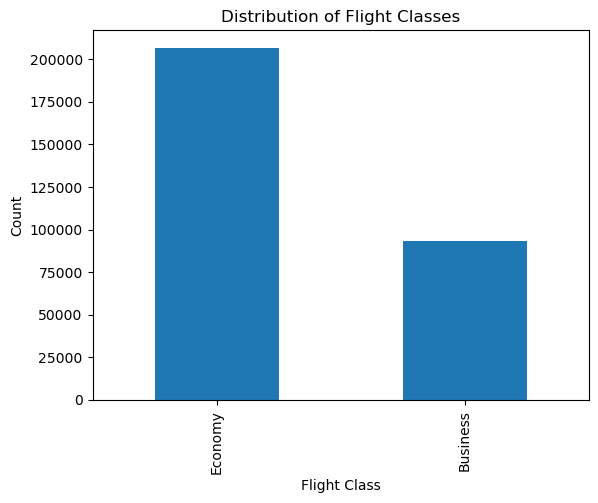

In [100]:
df['class'].value_counts().plot(kind='bar')
plt.title('Distribution of Flight Classes')
plt.xlabel('Flight Class')
plt.ylabel('Count')
plt.show()

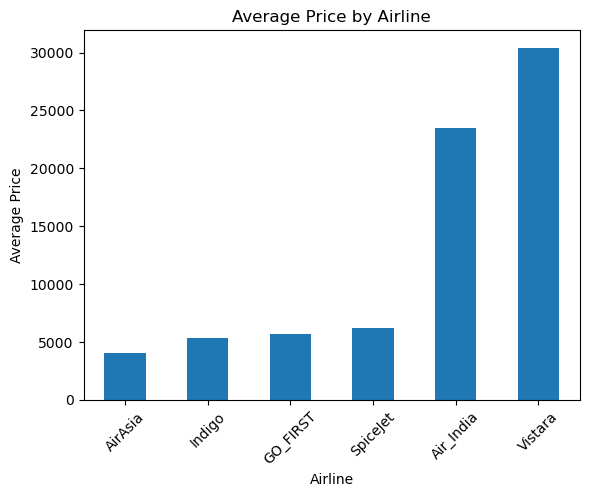

In [101]:
df.groupby('airline')['price'].mean().sort_values().plot(kind='bar')
plt.title('Average Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

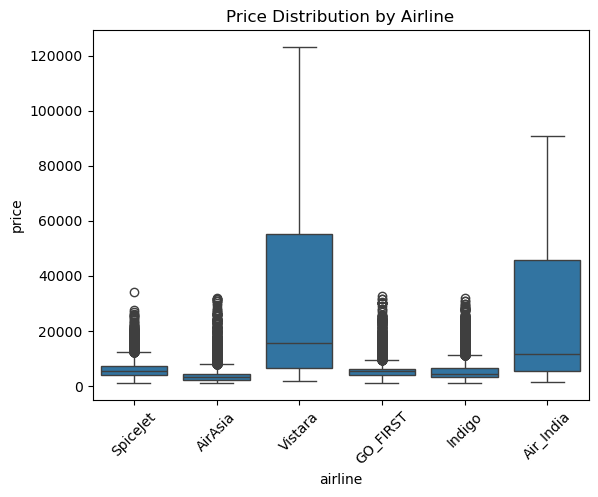

In [102]:
sns.boxplot(x='airline', y='price', data=df)
plt.title("Price Distribution by Airline")
plt.xticks(rotation=45)
plt.show()

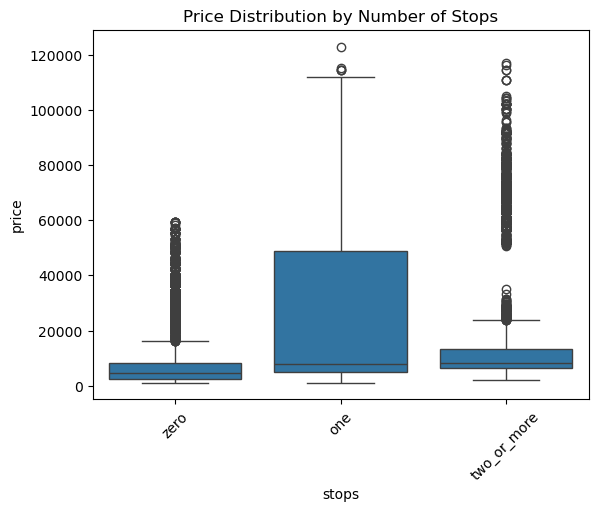

In [103]:
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price Distribution by Number of Stops")
plt.xticks(rotation=45)
plt.show()

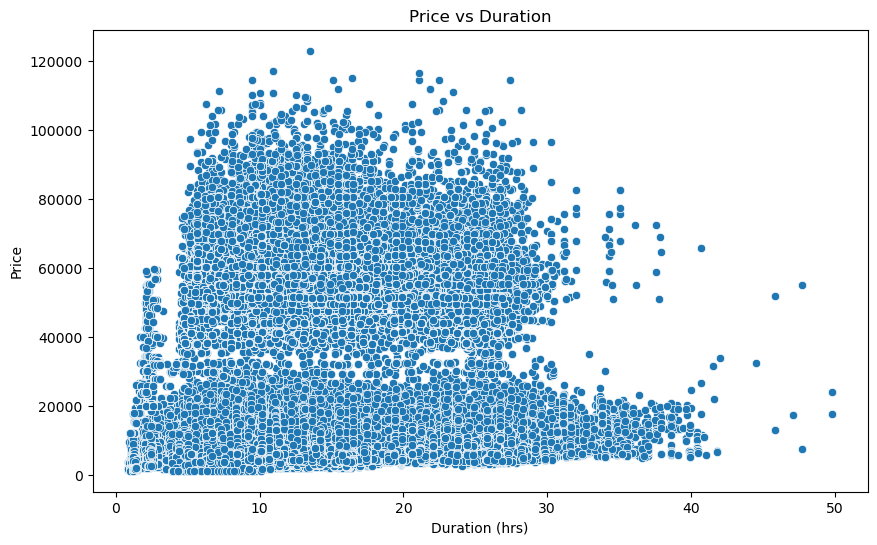

In [104]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='price', data=df)
plt.title('Price vs Duration')
plt.xlabel('Duration (hrs)')
plt.ylabel('Price')
plt.show()

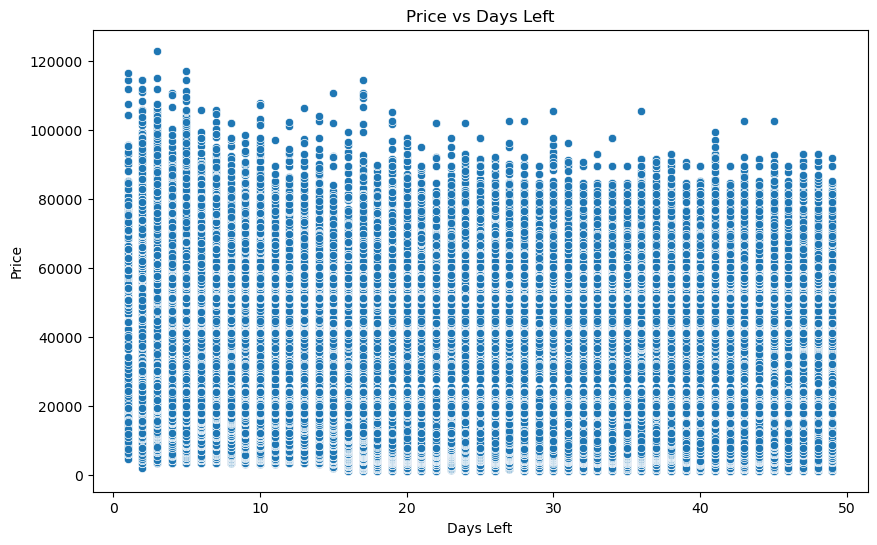

In [105]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='days_left', y='price', data=df)
plt.title('Price vs Days Left')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.show()

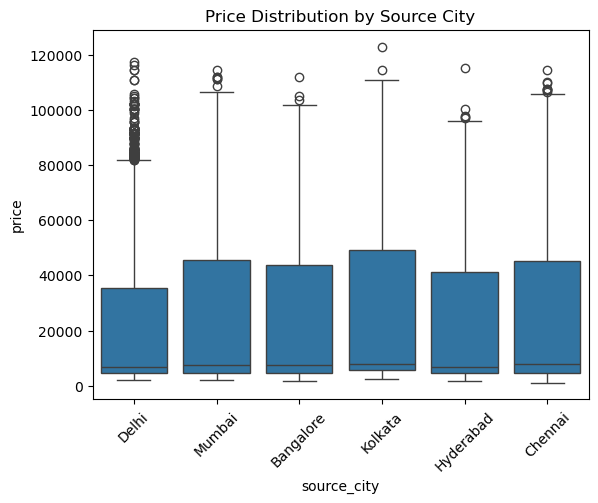

In [106]:
sns.boxplot(x='source_city', y='price', data=df)
plt.title("Price Distribution by Source City")
plt.xticks(rotation=45)
plt.show()

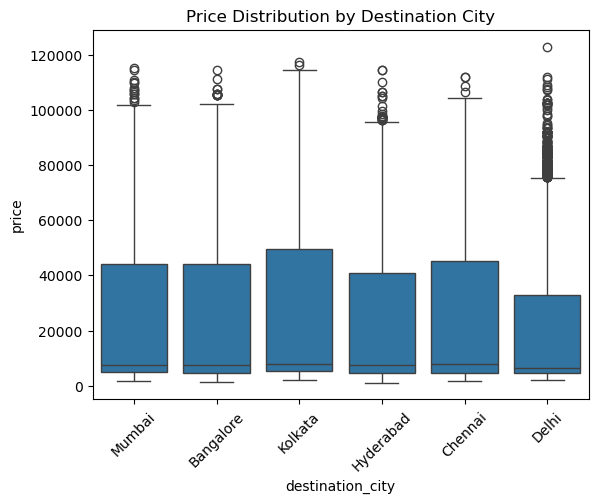

In [107]:
sns.boxplot(x='destination_city', y='price', data=df)
plt.title("Price Distribution by Destination City")
plt.xticks(rotation=45)
plt.show()

# Encoding

In [87]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [114]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])
df['stops'] = le.fit_transform(df['stops'])

In [115]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,2,Night,Mumbai,1,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,2,Morning,Mumbai,1,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,2,Early_Morning,Mumbai,1,2.17,1,5956
3,Vistara,Delhi,Morning,2,Afternoon,Mumbai,1,2.25,1,5955
4,Vistara,Delhi,Morning,2,Morning,Mumbai,1,2.33,1,5955


In [116]:
cols = ['airline', 'source_city', 'departure_time', 'arrival_time','destination_city']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index=df.index)

In [117]:
encoded_df.head()

,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [118]:
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)
df.head()

,stops,class,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,2,1,2.17,1,5953,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,1,2.33,1,5953,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,1,2.17,1,5956,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2,1,2.25,1,5955,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,1,2.33,1,5955,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [119]:
df.describe()

,stops,class,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
count,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,...,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000
mean,0.284168,0.688536,12.221021,26.004751,20889.660523,0.269503,0.077204,0.143660,0.030021,0.425979,...,0.051364,0.260944,0.046646,0.209010,0.304971,0.134491,0.191103,0.142347,0.165029,0.196890
std,0.665825,0.463093,7.191997,13.561004,22697.767366,0.443702,0.266915,0.350745,0.170646,0.494491,...,0.220739,0.439150,0.210880,0.406602,0.460396,0.341180,0.393170,0.349407,0.371207,0.397649
min,0.000000,0.000000,0.830000,1.000000,1105.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.830000,15.000000,4783.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,11.250000,26.000000,7425.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,16.170000,38.000000,42521.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,1.000000,49.830000,49.000000,123071.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         300153 non-null  int64  
 1   class                         300153 non-null  int64  
 2   duration                      300153 non-null  float64
 3   days_left                     300153 non-null  int64  
 4   price                         300153 non-null  int64  
 5   airline_Air_India             300153 non-null  float64
 6   airline_GO_FIRST              300153 non-null  float64
 7   airline_Indigo                300153 non-null  float64
 8   airline_SpiceJet              300153 non-null  float64
 9   airline_Vistara               300153 non-null  float64
 10  source_city_Chennai           300153 non-null  float64
 11  source_city_Delhi             300153 non-null  float64
 12  source_city_Hyderabad         300153 non-nul

# Correlation Heatmap

In [121]:
num_cols = df.select_dtypes(include=['number'])
corr_matrix = num_cols.corr()

In [122]:
num_cols.corr()['price'].sort_values(ascending=False)

price                           1.000000
airline_Vistara                 0.360816
duration                        0.204222
airline_Air_India               0.070041
arrival_time_Evening            0.056408
departure_time_Night            0.041768
arrival_time_Morning            0.030379
destination_city_Kolkata        0.020956
arrival_time_Night              0.020344
source_city_Chennai             0.018742
destination_city_Chennai        0.018473
departure_time_Morning          0.018199
source_city_Kolkata             0.016127
source_city_Mumbai              0.013206
destination_city_Mumbai         0.010533
departure_time_Evening          0.007946
destination_city_Hyderabad     -0.008292
departure_time_Early_Morning   -0.012232
source_city_Hyderabad          -0.012828
departure_time_Late_Night      -0.033768
source_city_Delhi              -0.043282
destination_city_Delhi         -0.052527
arrival_time_Early_Morning     -0.060449
days_left                      -0.091949
arrival_time_Lat

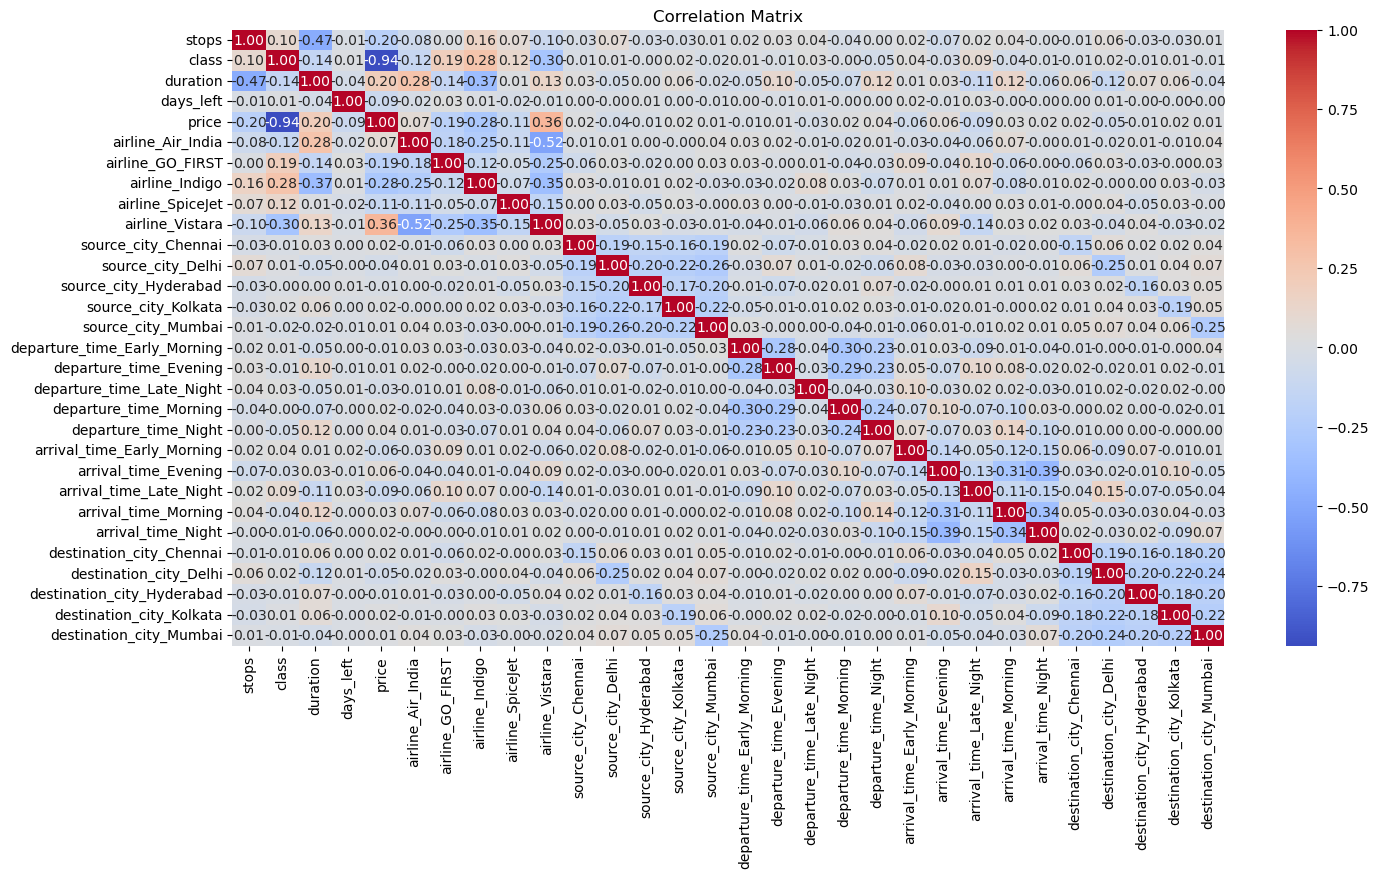

In [123]:
plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Train-Test-Split + Feature Scaling

In [124]:
X = df.drop("price", axis=1)
y = df["price"]

In [125]:
X.head()

,stops,class,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,2,1,2.17,1,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,1,2.33,1,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,1,2.17,1,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2,1,2.25,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,1,2.33,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [126]:
y.head()

0    5953
1    5953
2    5956
3    5955
4    5955
Name: price, dtype: int64

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
X_test.head()

,stops,class,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
27131,0,1,19.75,40,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
266857,0,0,9.83,42,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
141228,0,1,10.50,41,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
288329,0,0,14.50,14,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
97334,0,1,8.25,20,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
X_train_scaled

array([[-0.42755489,  0.67246146,  1.00173042, ..., -0.40677437,
        -0.44439907, -0.49534037],
       [ 1.07254498,  0.67246146, -0.72463441, ..., -0.40677437,
        -0.44439907, -0.49534037],
       [-0.42755489, -1.48707407,  1.24497828, ..., -0.40677437,
        -0.44439907, -0.49534037],
       ...,
       [-0.42755489,  0.67246146,  0.20248744, ..., -0.40677437,
        -0.44439907,  2.01881383],
       [-0.42755489,  0.67246146, -0.53976604, ...,  2.45836529,
        -0.44439907, -0.49534037],
       [-0.42755489,  0.67246146,  1.1059795 , ..., -0.40677437,
        -0.44439907, -0.49534037]], shape=(240122, 29))

In [131]:
X_test_scaled

array([[-0.42755489,  0.67246146,  1.04760002, ..., -0.40677437,
         2.25022971, -0.49534037],
       [-0.42755489, -1.48707407, -0.33126787, ..., -0.40677437,
        -0.44439907,  2.01881383],
       [-0.42755489,  0.67246146, -0.23813869, ..., -0.40677437,
        -0.44439907, -0.49534037],
       ...,
       [-0.42755489,  0.67246146,  0.18997755, ..., -0.40677437,
        -0.44439907, -0.49534037],
       [ 2.57264485,  0.67246146, -1.41962831, ..., -0.40677437,
         2.25022971, -0.49534037],
       [-0.42755489, -1.48707407,  1.83572309, ..., -0.40677437,
        -0.44439907, -0.49534037]], shape=(60031, 29))

# Best Model on the basis of R2 Score --> Naive Bayes

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression":       LinearRegression(),
    "KNN":                     KNeighborsRegressor(n_neighbors=5),
    "Decision Tree":           DecisionTreeRegressor(random_state=42),
    "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":       GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost":                AdaBoostRegressor(n_estimators=100, random_state=42),
    "Extra Trees":             ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Bagging":                 BaggingRegressor(n_estimators=100, random_state=42),
    "SVM":                     SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "XGBoost":                 XGBRegressor(eval_metric='rmse', random_state=42),
}

results = []

for name, model in models.items():
    
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "R^2 Score": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "MSE": round(mean_squared_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    })

results_df = pd.DataFrame(results).sort_values("R^2 Score", ascending=False)
results_df